In [1]:
import os
import torch

from sensorium.utility import get_data, set_random_seed
from sensorium.models import stacked_core_full_gauss_readout, stacked_core_factorized_readout

from utils import load_model_from_config, get_knn_curve, get_ari_curve
import matplotlib.pyplot as plt

random_seed = 42
set_random_seed(random_seed, deterministic=False)

device = 'cuda:7'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"
# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]

if False:
    more_basepath = "/user/turishcheva/more_data_like_sensorium_2022"
    for file in [
        "static20457-5-9-94c6ff995dac583098847cfecd43e7b6",
        "static20622-2-14-94c6ff995dac583098847cfecd43e7b6",
        "static20892-10-10-94c6ff995dac583098847cfecd43e7b6",
        "static22223-2-15-94c6ff995dac583098847cfecd43e7b6",
        "static22564-2-12-94c6ff995dac583098847cfecd43e7b6",
        "static22620-4-15-94c6ff995dac583098847cfecd43e7b6",
        "static23555-5-12-94c6ff995dac583098847cfecd43e7b6",
    ]:
        filenames.append(os.path.join(more_basepath, file))

dataset_fn = "sensorium.datasets.static_loaders"

dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "exclude_eye_position_paths": [
        '/srv/user/polina/sensorium/sensorium/notebooks/data/static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6.zip'
    ],
    "batch_size": 128,
    "scale": 0.25,
}
dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

fact_config = {
    'hidden_channels': 96, # original sensorium was 64ch
    'depth_separable': False,
    'use_avg_reg': False,
    'laplace_padding': None,
    'momentum': 0.75,
    'final_nonlinearity': True,
    'nonlinearity_type': 'AdaptiveELU',
    'pad_input': False,
    'hidden_padding': None, 
    'stack': -1,
    'layers': 4,
    'input_kern': 9, #  original sensorium was 'input_kern': 9,
    'gamma_input': 6.3831, # this should not influence the performance based on previous experience
    
    'feature_reg_weight': 1.0, # this is the one I actually would like to tune!
    
    'hidden_kern': 7,
    
    'shifter': True,
    'shifter_bias': False,
    'hidden_channels_shifter': 5,
    'shift_layers': 1,
    'batch_norm_scale': [True, True, True, False],
    'core_bias': [True, True, True, False],
    'regularizer_type': 'adaptive_log_norm',
    'gamma_sigma': 0.25,
    #'readout_type': args.readout_type,
    # 'discretized_spatial': args.discretized,
    # 'kernel_size': args.kernel_size,
    # 'sigma': args.sigma,
    'init_gain': 0.1,
    'whitener': True,
    'whitener_momentum': 0.003,
}

import copy
gauss_config = copy.deepcopy(fact_config)
gauss_config['grid_mean_predictor'] = {
    'type': 'cortex',
    'input_dimensions': 2,
    'hidden_layers': 0,
    'hidden_features': 30,
    'final_tanh': True
}
gauss_config['init_sigma'] = 0.1
gauss_config['init_mu_range'] = 0.3
gauss_config['gauss_type'] = 'full'

In [2]:
def remap_state_dict(state_dict):
    renamed = {}
    for k, v in state_dict.items():
        new_k = k.replace("mask_weights", "spatial_w").replace("mask_bias", "spatial_b")
        if new_k.endswith("spatial_w") or new_k.endswith("spatial_b"):
            if v.dim() == 4 and v.shape[1] == 1:
                v = v.squeeze(1)
        renamed[new_k] = v
    return renamed

In [3]:
gauss_paths = [
    '../training/runs/gaussian_seed0/model_weights.pth',
    '../training/runs/gaussian_seed42/model_weights.pth',
    '../training/runs/gaussian_seed123/model_weights.pth',
]
fact_paths = [
    '../training/runs/factorized_seed0/model_weights.pth',
    '../training/runs/factorized_seed42/model_weights.pth',
    '../training/runs/factorized_seed123/model_weights.pth',
]

gauss_models = []
for path in gauss_paths:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **gauss_config)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval();
    gauss_models.append(model)

fact_models = []
for path in fact_paths:
    model = stacked_core_factorized_readout(dataloaders, random_seed, **fact_config)
    model.load_state_dict(remap_state_dict(torch.load(path, map_location=device)))
    model.to(device)
    model.eval();
    fact_models.append(model)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [4]:
gauss_readouts = []
for model in gauss_models:
    r = torch.cat([model.readout[key].features.detach().squeeze().T for key in data_keys])
    r = model.whitener.transform_weights(r.T).T.cpu()
    gauss_readouts.append(r)

gauss_curve, k_range = get_knn_curve(gauss_readouts)

In [5]:
fact_readouts = []
for model in fact_models:
    r = torch.cat([model.readout[key].features.detach() for key in data_keys])
    r = model.whitener.transform_weights(r.T).T.cpu()
    fact_readouts.append(r)

fact_curve, k_range = get_knn_curve(fact_readouts)

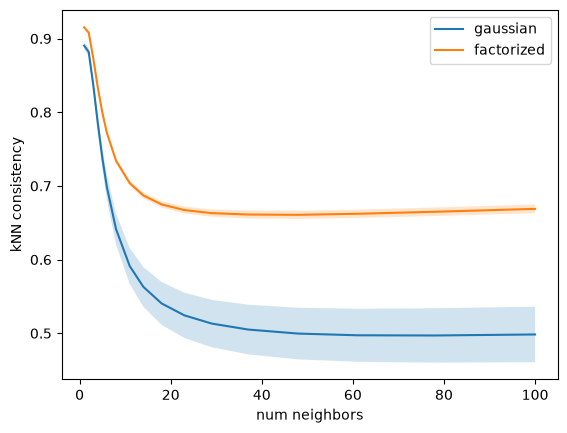

In [7]:
m, s = gauss_curve[0], gauss_curve[1]
plt.plot(k_range, m, label='gaussian')
plt.fill_between(k_range, m - s, m + s, alpha=0.2)

m, s = fact_curve[0], fact_curve[1]
plt.plot(k_range, m, label='factorized')
plt.fill_between(k_range, m - s, m + s, alpha=0.2)

plt.xlabel('num neighbors')
plt.ylabel('kNN consistency')
plt.legend()
plt.show()

# receptive fields

In [10]:
h, w = 28, 56
gauss_grids = []
for model in gauss_models:
    grids = []
    for key in data_keys:
        grid = model.readout[key].sample_grid(1, sample=False).squeeze().detach().cpu()
        grid[:, 0] = (grid[:, 0] + 1) / 2 * w
        grid[:, 1] = (grid[:, 1] + 1) / 2 * h

        grids.append(grid)

    gauss_grids.append(grids)

In [11]:
fact_grids = []
for model in fact_models:
    grids = []
    for key in data_keys:
        spatial = model.readout[key].spatial.detach().cpu()
        n, h, w = spatial.shape
        y = spatial.sum(dim=2)  # n, h
        x = spatial.sum(dim=1)  # n, w

        y_pos = torch.arange(h).unsqueeze(0).expand(n, h)
        x_pos = torch.arange(w).unsqueeze(0).expand(n, w)

        y_avg = (y_pos * y).sum(dim=1)
        x_avg = (x_pos * x).sum(dim=1)
        
        grid = torch.stack([x_avg, y_avg], dim=1)
        grids.append(grid)

    fact_grids.append(grids)

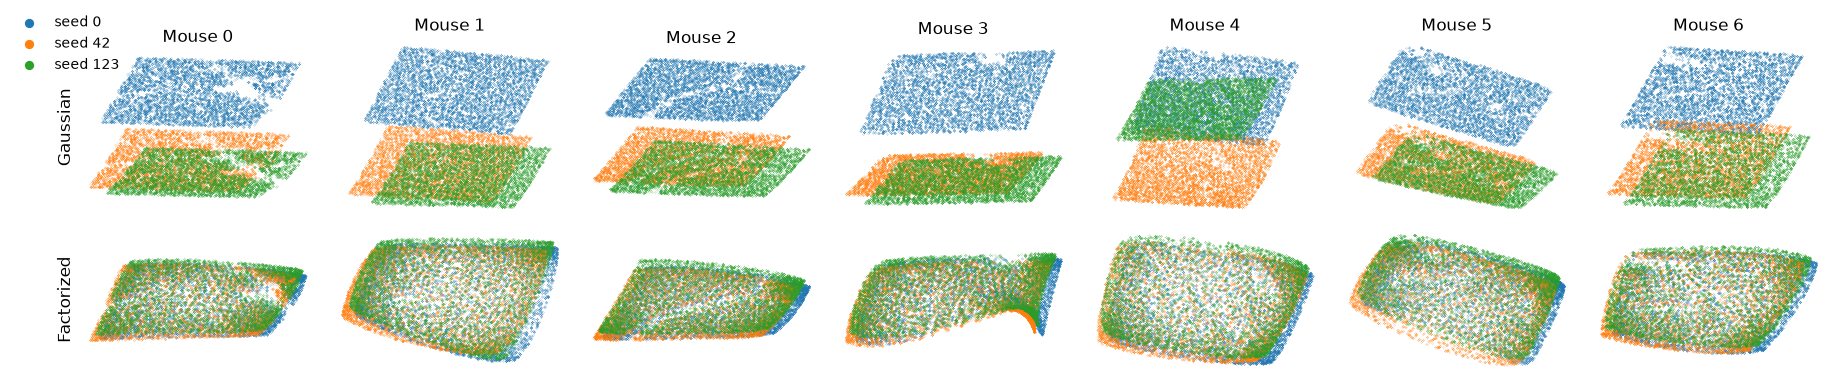

In [12]:
import matplotlib.pyplot as plt

model_seeds = [0, 42, 123]
model_types = {
    "Gaussian": gauss_grids,
    "Factorized": fact_grids,
}

num_mice = len(gauss_grids[0])
num_models = len(model_seeds)

fig, axs = plt.subplots(len(model_types), num_mice, figsize=(18, 4))

for row_idx, (type_name, grids) in enumerate(model_types.items()):
    for mouse_idx in range(num_mice):
        ax = axs[row_idx, mouse_idx]
        for model_idx in range(num_models):
            grid = grids[model_idx][mouse_idx]
            ax.scatter(
                grid[:, 0], grid[:, 1],
                alpha=1, s=0.02,
                label=f"seed {model_seeds[model_idx]}",
            )
        ax.set_aspect('equal')

        # remove spines and ticks
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])

        # column labels on top row only
        if row_idx == 0:
            ax.set_title(f"Mouse {mouse_idx}")

        # row labels on first column only
        if mouse_idx == 0:
            ax.set_ylabel(type_name, rotation=90, size='large')

# single shared legend for seeds (bigger markers than the tiny scatter points)
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    bbox_to_anchor=(0.05, 1.0),
    markerscale=40,
    frameon=False,
)

plt.tight_layout()
plt.show()

In [13]:
for type_name, grids in model_types.items():
    grids = [torch.cat(g) for g in grids]
    avgs = []
    print(type_name)
    for i, j in [[0, 1], [0, 2], [1, 2]]:
        d = (grids[i] - grids[j]).pow(2).sum(1).sqrt()
        avg = d.mean()
        avgs.append(avg)
        print(f'between seeds: {model_seeds[i]}, {model_seeds[j]}: {avg} pixels')
    print()

Gaussian
between seeds: 0, 42: 5.4810051918029785 pixels
between seeds: 0, 123: 5.492839336395264 pixels
between seeds: 42, 123: 2.0327329635620117 pixels

Factorized
between seeds: 0, 42: 0.551292359828949 pixels
between seeds: 0, 123: 0.399761438369751 pixels
between seeds: 42, 123: 0.4545445740222931 pixels



# shifters

In [82]:
gauss_shifts = []
for model in gauss_models:
    shifts = []
    for key in data_keys:
        shift_batches = []
        for batch in dataloaders['validation'][key]:
            if len(batch) == 4:
                _, _, _, pupil = batch

                shift = model.shifter[key](pupil).detach().cpu()
                shift[:, 0] = (shift[:, 0]) / 2 * w  # rescale to from [-1, 1] to [0, w] 
                shift[:, 1] = (shift[:, 1]) / 2 * h  # rescale to from [-1, 1] to [0, h]
                shift_batches.append(shift)
        if len(shift_batches) > 0:
            shifts.append(torch.cat(shift_batches))
        else:
            shifts.append(torch.empty(0, 2))
    gauss_shifts.append(shifts)

In [83]:
fact_shifts = []
for model in fact_models:
    shifts = []
    for key in data_keys:
        shift_batches = []
        for batch in dataloaders['validation'][key]:
            if len(batch) == 4:
                _, _, _, pupil = batch

                shift = model.shifter[key](pupil).detach().cpu()
                shift[:, 0] = -(shift[:, 0]) / 2 * w  # rescale to from [-1, 1] to [0, w] 
                shift[:, 1] = -(shift[:, 1]) / 2 * h  # rescale to from [-1, 1] to [0, h]
                shift_batches.append(shift)
        if len(shift_batches) > 0:
            shifts.append(torch.cat(shift_batches))
        else:
            shifts.append(torch.empty(0, 2))
    fact_shifts.append(shifts)

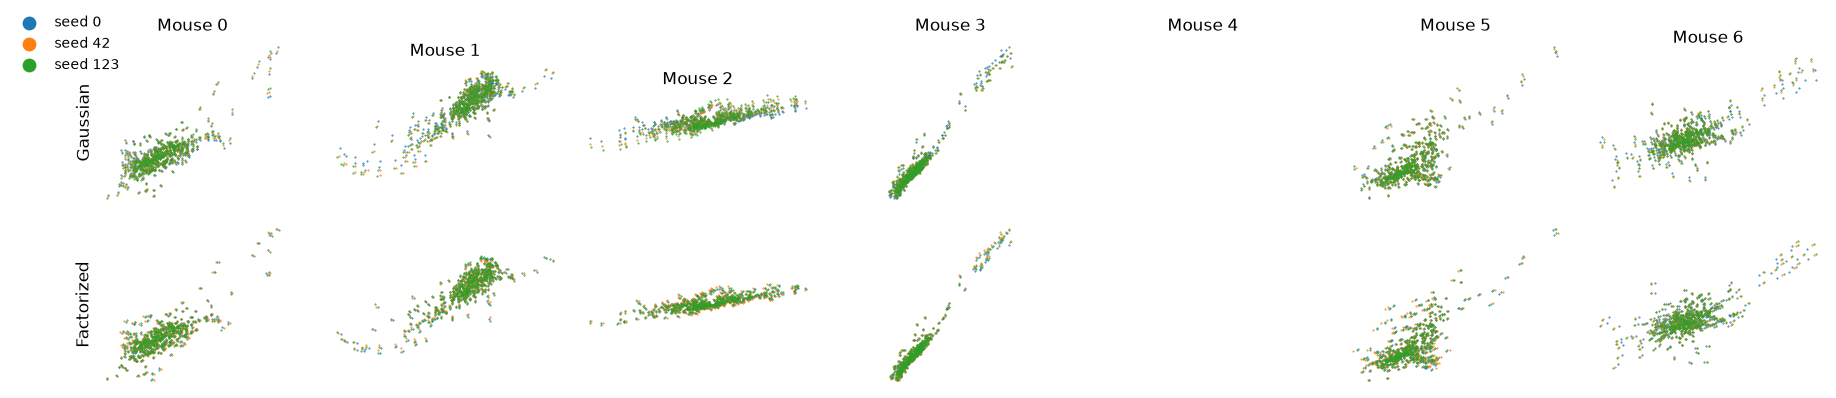

In [84]:
import matplotlib.pyplot as plt

model_seeds = [0, 42, 123]
model_types = {
    "Gaussian": gauss_shifts,
    "Factorized": fact_shifts,
}

num_mice = len(gauss_grids[0])
num_models = len(model_seeds)

fig, axs = plt.subplots(len(model_types), num_mice, figsize=(18, 4))

for row_idx, (type_name, shifts) in enumerate(model_types.items()):
    for mouse_idx in range(num_mice):
        ax = axs[row_idx, mouse_idx]
        for model_idx in range(num_models):
            shift = shifts[model_idx][mouse_idx]
            if shift is not None:
                ax.scatter(
                    shift[:, 0], shift[:, 1],
                    alpha=1, s=0.2,
                    label=f"seed {model_seeds[model_idx]}",
                )
        ax.set_aspect('equal')

        # remove spines and ticks
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])

        # column labels on top row only
        if row_idx == 0:
            ax.set_title(f"Mouse {mouse_idx}")

        # row labels on first column only
        if mouse_idx == 0:
            ax.set_ylabel(type_name, rotation=90, size='large')

# single shared legend for seeds (bigger markers than the tiny scatter points)
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    bbox_to_anchor=(0.05, 1.0),
    markerscale=20,
    frameon=False,
)

plt.tight_layout()
plt.show()

In [86]:
for type_name, shifts in model_types.items():
    shifts = [torch.cat(g) for g in shifts]
    avgs = []
    print(type_name)
    for i, j in [[0, 1], [0, 2], [1, 2]]:
        d = (shifts[i] - shifts[j]).pow(2).sum(1).sqrt()
        avg = d.mean()
        avgs.append(avg)
        print(f'between seeds: {model_seeds[i]}, {model_seeds[j]}: {avg} pixels')
    print()

Gaussian
between seeds: 0, 42: 0.047271329909563065 pixels
between seeds: 0, 123: 0.05944953113794327 pixels
between seeds: 42, 123: 0.022850073873996735 pixels

Factorized
between seeds: 0, 42: 0.03629482910037041 pixels
between seeds: 0, 123: 0.029704466462135315 pixels
between seeds: 42, 123: 0.02916676178574562 pixels

